# Practical No. 1 — Healthcare ML Pipeline: Ethical Data Handling and Regression Modelling

**Course:** HMLAL701 — AI & ML Laboratory
**Dataset:** BRFSS 2015 Diabetes Health Indicators (`diabetes_binary_health_indicators_BRFSS2015.csv`)
**Target variable:** `BMI` (continuous) — this practical is a **regression** task, not classification.

**Problem statement:** a regional hospital network wants to predict a patient's BMI from their
lifestyle and health indicators, to help flag patients at risk of diabetes-related complications.
This notebook builds an ethical, privacy-aware pipeline: load → EDA → privacy audit → clean →
feature engineer → scale → split → train Linear Regression → evaluate → reflect on ethics → save model.

## Step 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## Step 1 — Data Collection

Load the raw CSV and confirm its shape before doing anything else.

In [2]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

print("Shape (rows, columns):", df.shape)
df.head(10)

Shape (rows, columns): (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


## Step 2 — Exploratory Data Analysis (EDA)

Look at structure, distributions, and relationships before changing anything.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


**Missing values check:**

In [5]:
missing = df.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "None found.")

Columns with missing values:
None found.


**Distributions of all features** (spot skew/outliers before modelling):

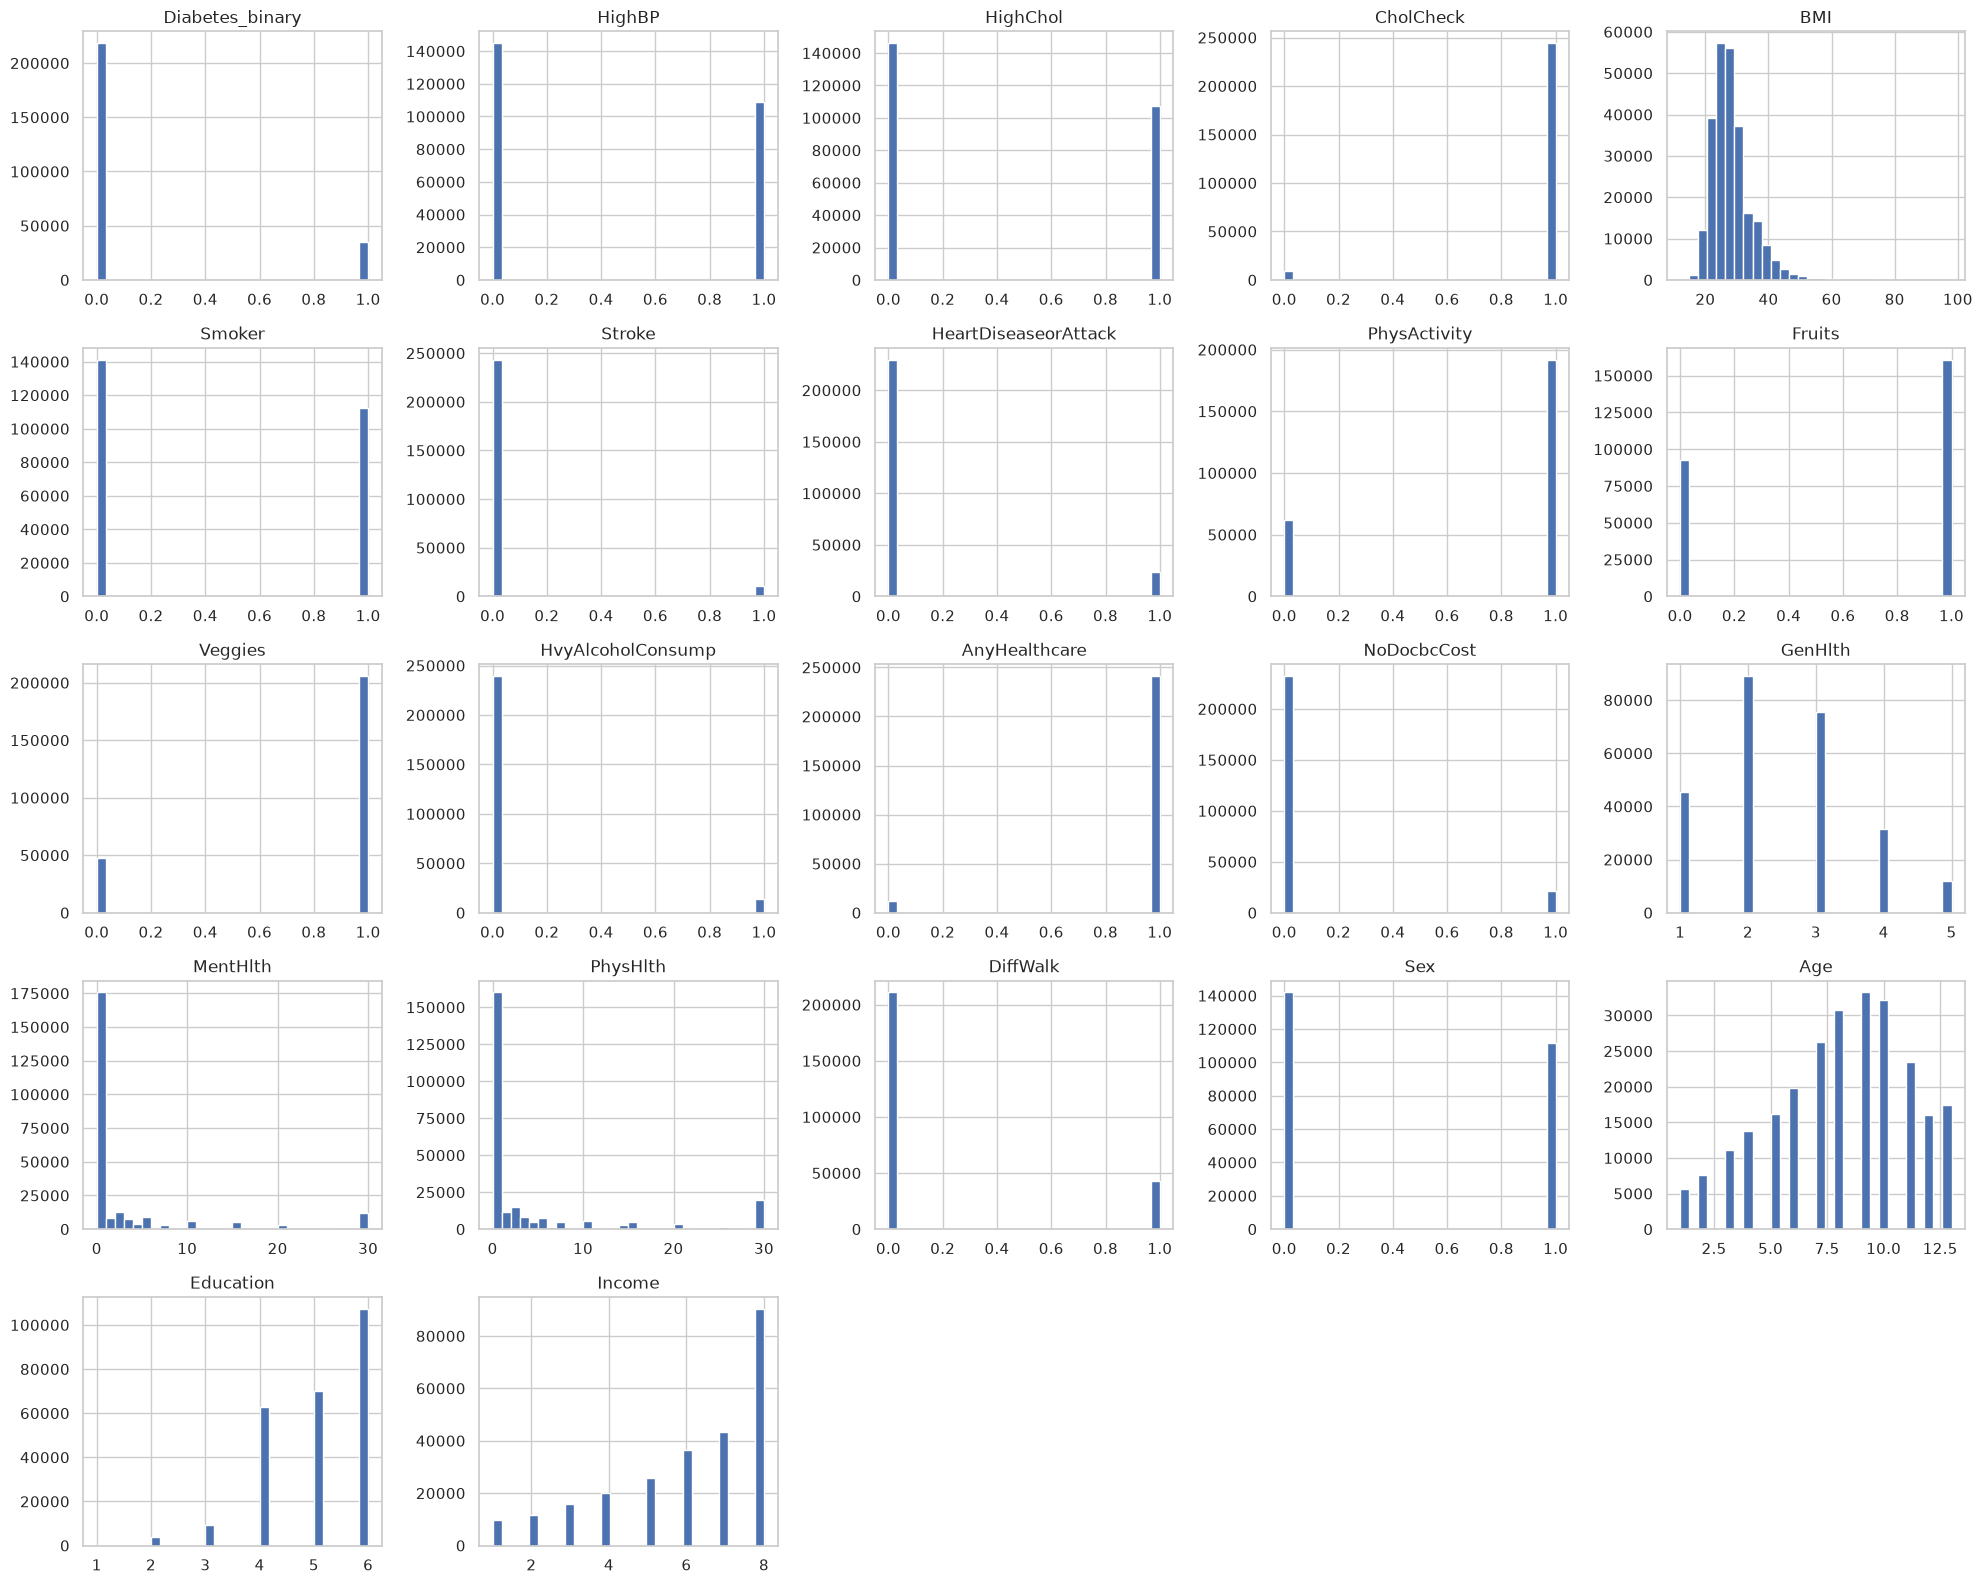

In [6]:
df.hist(figsize=(20, 16), bins=30)
plt.tight_layout()
plt.show()

**Correlation heatmap** (all features, including the regression target `BMI`):

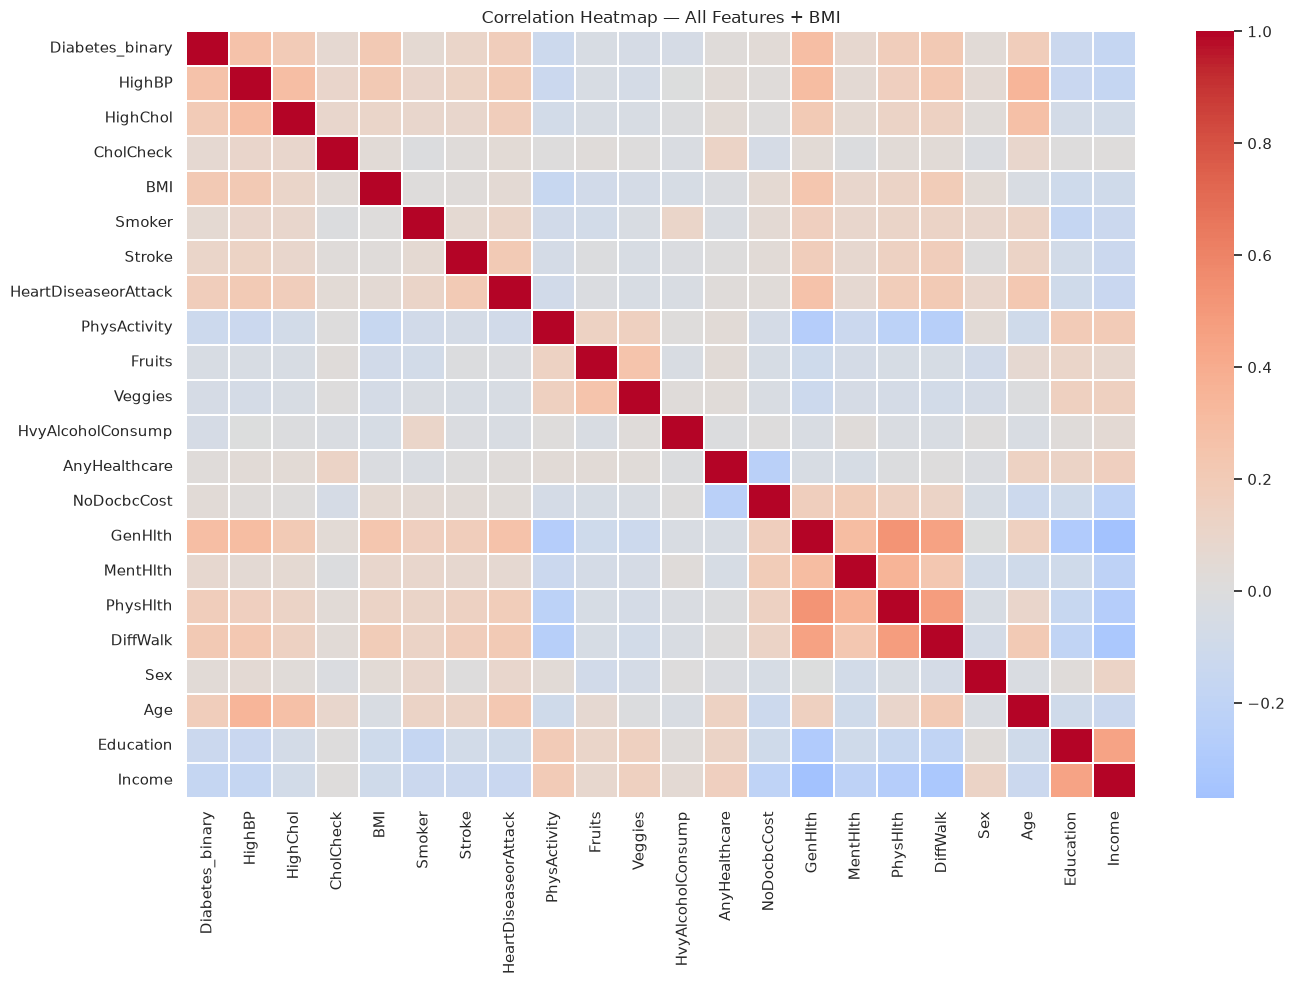

In [7]:
corr = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap — All Features + BMI")
plt.tight_layout()
plt.show()

In [8]:
bmi_corr = corr["BMI"].drop("BMI").sort_values(key=abs, ascending=False)
print("Feature correlation with BMI (strongest first):")
print(bmi_corr)

Feature correlation with BMI (strongest first):
GenHlth                 0.239185
Diabetes_binary         0.216843
HighBP                  0.213748
DiffWalk                0.197078
PhysActivity           -0.147294
PhysHlth                0.121141
HighChol                0.106722
Education              -0.103932
Income                 -0.100069
Fruits                 -0.087518
MentHlth                0.085310
Veggies                -0.062275
NoDocbcCost             0.058206
HeartDiseaseorAttack    0.052904
HvyAlcoholConsump      -0.048736
Sex                     0.042950
Age                    -0.036618
CholCheck               0.034495
Stroke                  0.020153
AnyHealthcare          -0.018471
Smoker                  0.013804
Name: BMI, dtype: float64


## Step 3 — Privacy Audit

Before any modelling, document what personally identifiable information (PII) exists and what's
done about it — this is a hospital-data pipeline, so this step is not optional.

**Audit result:** this dataset is a public BRFSS (CDC survey) export. It contains **no direct
identifiers** — no name, address, phone number, or Aadhaar/SSN-equivalent field. Respondents are
already anonymized at the source by the CDC before release. There is nothing to drop here, but the
audit itself — actively checking rather than assuming — is the required step, and is documented
here for that reason.

**Residual risk to note:** even fully anonymized data carries re-identification risk when several
fields are combined (e.g. `Age` bucket + `Sex` + `Income` bucket + `Education` could narrow a
respondent down in combination with outside information). No further masking is applied here since
none of the features in this dataset are precise enough on their own to re-identify someone, but
this is worth stating explicitly in a real deployment rather than assumed safe.

## Step 4 — Data Cleaning

Same checklist as any tabular dataset: duplicates, invalid values, correct dtypes, and missing-value
handling.

In [9]:
# Duplicate rows
dupe_count = df.duplicated().sum()
print(f"Duplicate rows found: {dupe_count}")

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows found: 24206
Shape after dropping duplicates: (229474, 22)


In [10]:
# Data types — tighten binary/coded columns from float64 to int
binary_cols = ["Diabetes_binary", "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
               "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
               "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"]
int_coded_cols = ["GenHlth", "Age", "Education", "Income"]

df[binary_cols] = df[binary_cols].astype(int)
df[int_coded_cols] = df[int_coded_cols].astype(int)
df.dtypes

Diabetes_binary           int64
HighBP                    int64
HighChol                  int64
CholCheck                 int64
BMI                     float64
Smoker                    int64
Stroke                    int64
HeartDiseaseorAttack      int64
PhysActivity              int64
Fruits                    int64
Veggies                   int64
HvyAlcoholConsump         int64
AnyHealthcare             int64
NoDocbcCost               int64
GenHlth                   int64
MentHlth                float64
PhysHlth                float64
DiffWalk                  int64
Sex                       int64
Age                       int64
Education                 int64
Income                    int64
dtype: object

**Missing-value imputation:** the check above already found zero missing values, so this is a
no-op on this dataset — but a production healthcare pipeline should never assume the *next* data
export will also be complete, so the imputer is included anyway rather than skipped.

In [11]:
imputer = SimpleImputer(strategy="mean")
df[df.columns] = imputer.fit_transform(df)
print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


## Step 5 — Feature Engineering

Create a `BMI_Category` column (underweight / normal / overweight / obese) from the standard
clinical BMI bands — useful for reporting and sanity-checking the data, but note the warning below.

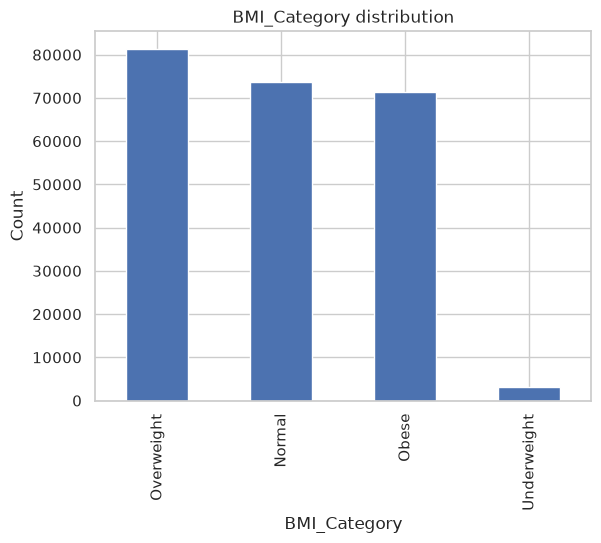

BMI_Category
Overweight     81414
Normal         73635
Obese          71373
Underweight     3052
Name: count, dtype: int64

In [12]:
bins = [0, 18.5, 25, 30, 100]
labels = ["Underweight", "Normal", "Overweight", "Obese"]
df["BMI_Category"] = pd.cut(df["BMI"], bins=bins, labels=labels)

df["BMI_Category"].value_counts().plot(kind="bar", title="BMI_Category distribution")
plt.ylabel("Count")
plt.show()
df["BMI_Category"].value_counts()

**Important — this column is NOT a model input.** `BMI_Category` is derived directly from `BMI`,
which is the regression target. Feeding it into the model would leak the answer into the input
(the model could just learn to reverse the bucketing) and would make the R²/MAE scores meaningless.
It's kept in the dataframe only for exploratory/reporting purposes and explicitly dropped before
building `X` below.

## Step 6 — Feature Scaling

Split into inputs (`X`) and target (`y = BMI`), then apply `StandardScaler` to the inputs. This
matters here because Linear Regression's coefficients are only directly comparable to each other
when every feature is on the same scale — otherwise a feature like `Income` (range 1-8) and one
like `MentHlth` (range 0-30) would look artificially more/less important just because of their raw
scale, not their actual relationship with BMI.

In [13]:
X = df.drop(columns=["BMI", "BMI_Category"])
y = df["BMI"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().T[["mean", "std"]]

,mean,std
Diabetes_binary,8.620371e-17,1.000002
HighBP,-1.367369e-16,1.000002
HighChol,-5.152406e-17,1.000002
CholCheck,-7.134100e-17,1.000002
Smoker,2.080779e-17,1.000002
Stroke,-4.855151e-17,1.000002
HeartDiseaseorAttack,6.836846e-17,1.000002
PhysActivity,-1.010664e-16,1.000002
Fruits,-3.963389e-18,1.000002
Veggies,1.089932e-17,1.000002


## Step 7 — Train/Test Split

Hold back 20% of the data to evaluate the model on data it never saw during training. `random_state=42`
makes the split reproducible.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (183579, 21)
Test shape:  (45895, 21)


## Step 8 — Train Linear Regression

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Step 9 — Predict and Evaluate

Four standard regression metrics:
- **MAE** (Mean Absolute Error) — average size of the error, in the same units as BMI.
- **MSE** (Mean Squared Error) — like MAE but squares errors first, so large mistakes are punished more.
- **RMSE** (Root MSE) — square-root of MSE, brought back into BMI units for interpretability.
- **R²** — fraction of the variance in BMI that the model explains (1.0 = perfect, 0.0 = no better
  than always guessing the average BMI).

In [16]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  4.5002
MSE:  40.3689
RMSE: 6.3537
R2:   0.1249


## Step 10 — Diagnostic Plots

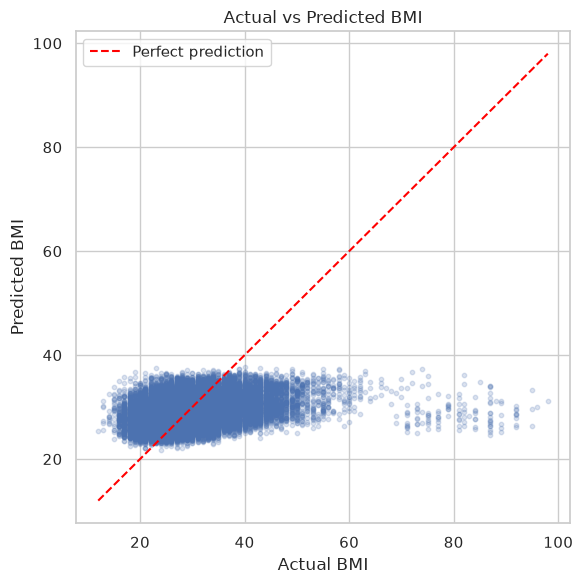

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI")
plt.legend()
plt.tight_layout()
plt.show()

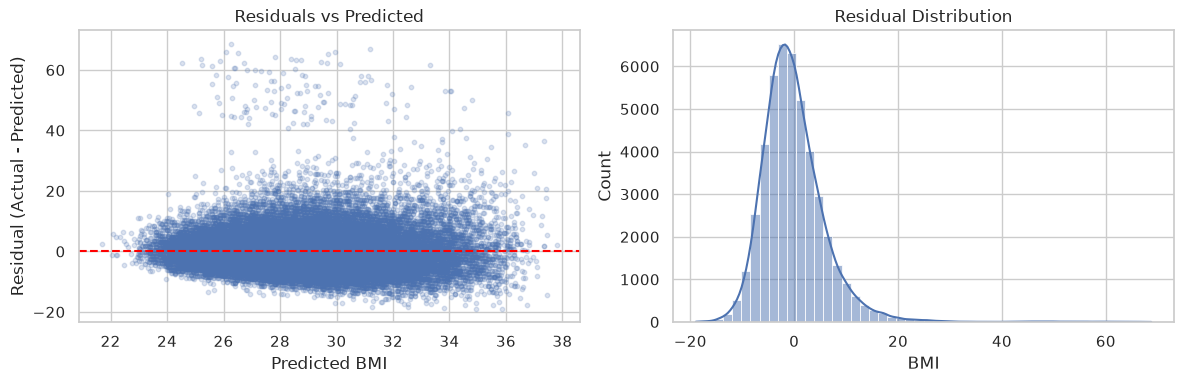

In [18]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.2, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted BMI")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, bins=50, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

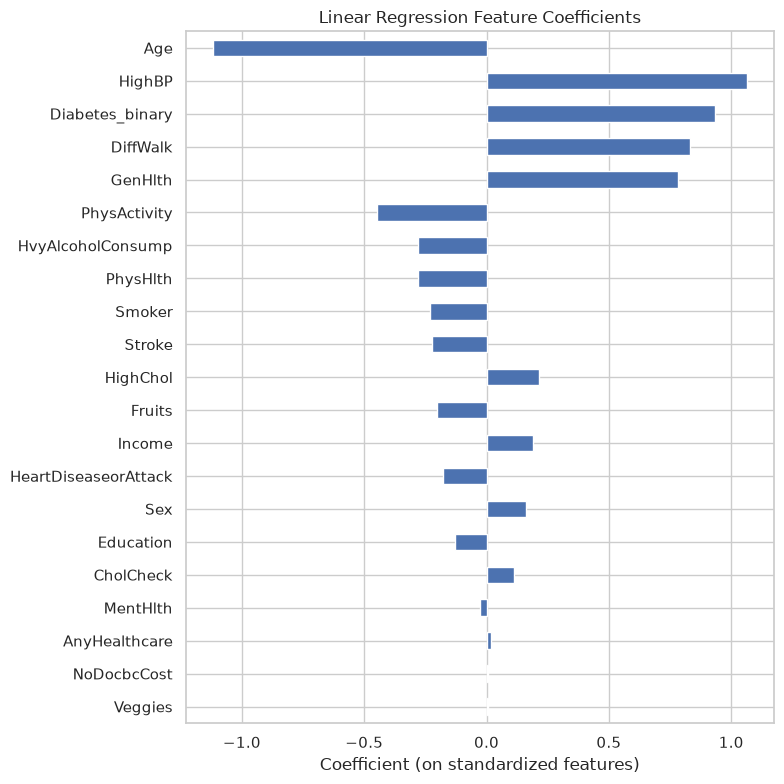

Age                    -1.119378
HighBP                  1.065553
Diabetes_binary         0.934442
DiffWalk                0.830853
GenHlth                 0.781559
PhysActivity           -0.448048
HvyAlcoholConsump      -0.280438
PhysHlth               -0.280274
Smoker                 -0.231797
Stroke                 -0.224624
HighChol                0.213449
Fruits                 -0.203857
Income                  0.190525
HeartDiseaseorAttack   -0.179565
Sex                     0.160819
Education              -0.128258
CholCheck               0.113973
MentHlth               -0.026494
AnyHealthcare           0.016960
NoDocbcCost             0.007487
Veggies                 0.005654
dtype: float64

In [19]:
coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 8))
coefs.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Coefficient (on standardized features)")
plt.title("Linear Regression Feature Coefficients")
plt.tight_layout()
plt.show()
coefs

## Step 11 — Result Analysis (Conclusion)

**What is the R² score of your model and what does it mean?**
R² ≈ **0.125** — the model explains about **12.5%** of the variance in BMI. That's low in absolute
terms, but it's an honest and expected result: BMI is driven heavily by factors this survey doesn't
capture at all (diet composition, genetics, exact exercise volume, metabolism), so a handful of
binary lifestyle/health flags were never going to explain most of it. The value is still useful —
it confirms these features carry *some* real signal about BMI, just not enough to fully predict it.

**Which features have the highest positive and negative coefficients? What does this imply
clinically?**
Highest positive: `HighBP` (+1.07), `Diabetes_binary` (+0.93), `DiffWalk` (+0.83), `GenHlth` (+0.78)
— all clinically sensible, since high blood pressure, diabetes, mobility difficulty, and poor
self-rated health are well-established comorbidities/consequences of higher BMI.
Highest negative: `Age` (-1.12), `PhysActivity` (-0.45), `HvyAlcoholConsump` (-0.28), `Smoker` (-0.23)
— physical activity lowering predicted BMI is expected; `Smoker` being negative matches a known
(if uncomfortable) epidemiological finding that nicotine suppresses appetite; `Age`'s negative
coefficient is more likely a cohort/survivorship effect in this survey population than a causal
relationship, and would be worth flagging as a caveat rather than a clinical claim.

**What was your MAE? Is this acceptable in a healthcare context?**
MAE ≈ **4.5** BMI points, against a mean test-set BMI of **~28.6** — roughly a 16% relative error.
That's too imprecise to use for an individual clinical decision (e.g. dosing or diagnosis), but
could plausibly support population-level screening (e.g. flagging patients worth a follow-up
health check), which matches the "risk of diabetes-related complications" framing in the problem
statement — not a diagnostic tool.

**What ethical concerns arose during preprocessing? How did you address them?**
Two: (1) privacy — even without direct identifiers, combinations of `Age`/`Sex`/`Income`/`Education`
buckets could narrow down a respondent, which was documented in the privacy audit rather than
ignored; (2) leakage — `BMI_Category` was engineered directly from the target and would have
silently inflated performance if used as a model input, so it was explicitly excluded and the
reasoning documented rather than just quietly dropped.

**How would you improve the model's performance? (suggest 2 techniques)**
1. **Try a non-linear model** (Random Forest or Gradient Boosting regressor) — R² this low with a
   linear model suggests the true relationship between these lifestyle indicators and BMI isn't
   purely linear/additive, and a tree-based model could capture interactions (e.g. the effect of
   `PhysActivity` on BMI may depend on `Age`) that Linear Regression structurally cannot.
2. **Add engineered interaction/polynomial features** (e.g. `Age × PhysActivity`, or squared terms
   for continuous columns) so the linear model can approximate some of that non-linearity without
   fully switching algorithms.

## Step 12 — Ethical, Societal and Environmental Reflection

**Privacy:** this dataset has no direct identifiers, but combinations of demographic buckets
(age/sex/income/education) still carry re-identification risk in principle — a real deployment
should treat "anonymized" as a spectrum, not a binary guarantee, and should document data
provenance and usage purpose (as done in the privacy audit step above).

**Bias:** BRFSS is a phone survey — response rates and coverage skew by age, income, and region.
A model trained on it can under-serve demographics that are underrepresented in the sample, and
that risk carries forward into any downstream BMI-based screening decision.

**Fairness:** a BMI-prediction tool used to flag "at-risk" patients should be audited for whether
its errors are evenly distributed across protected groups (e.g. sex, age band) before being used
to prioritize care, since a systematically biased error (e.g. under-predicting BMI for one group)
could mean that group gets flagged for follow-up less often than it should.

**Environmental impact:** Linear Regression is computationally cheap to train (this entire notebook
runs in seconds on a laptop CPU), so the environmental cost of this particular pipeline is
negligible — a deliberate advantage over the CNN/RNN/XGBoost models in later practicals, which
will have a real energy cost worth acknowledging at that point.

**Accountability:** clinicians using this model's output should be able to see *why* it predicted a
given BMI, not just the number — the coefficient bar chart above already gives that for free (a
benefit of choosing an interpretable linear model over a black-box one), and clinicians must retain
the ability to override the model's suggestion.

## Step 13 — Save the Model

Persist the trained model so it can be reloaded later without retraining.

In [20]:
joblib.dump(model, "diabetes_regression.pkl")
print("Model saved to diabetes_regression.pkl")

Model saved to diabetes_regression.pkl
